# Grafics and data things


In [329]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

df = pd.read_csv("../data/processed/full_dataset.csv")
df.head()

,title,text,subject,date,target,full_text,text_length,word_count,title_length,year,month,weekday
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31,0,republican faction congress who voted month hu...,1363,187,64,2017.0,12.0,6.0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29,0,allowed first time enlist military starting mo...,1431,189,64,2017.0,12.0,4.0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31,0,link between russia president election campaig...,1342,185,60,2017.0,12.0,6.0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12-30,0,told australian diplomat may russia had politi...,1510,208,59,2017.0,12.0,5.0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29,0,postal service friday charge much more ship pa...,1304,193,69,2017.0,12.0,4.0


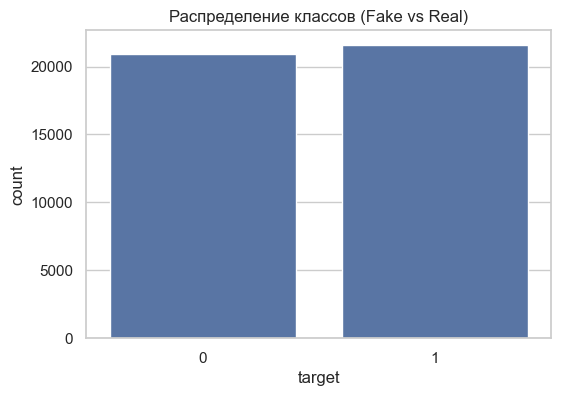

In [330]:
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Распределение классов (Fake vs Real)")
plt.show()

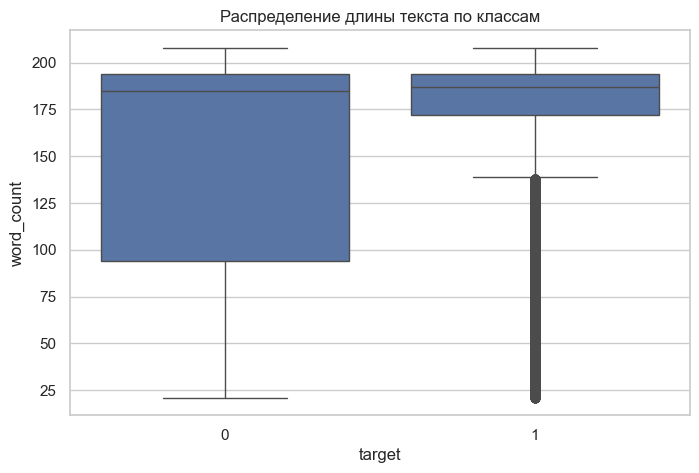

In [331]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="word_count", data=df)
plt.title("Распределение длины текста по классам")
plt.show()

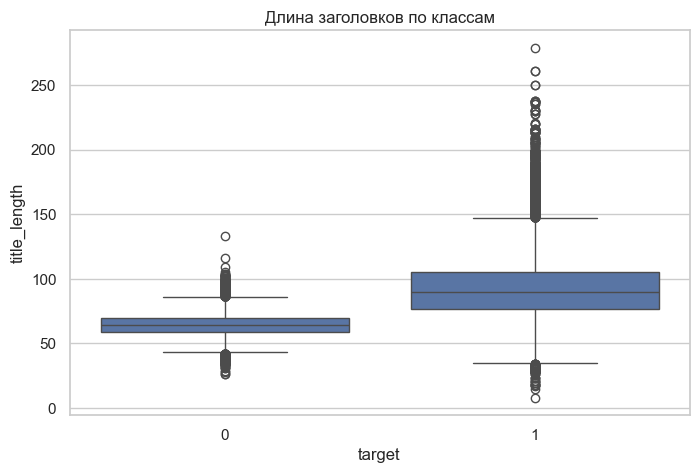

In [332]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="title_length", data=df)
plt.title("Длина заголовков по классам")
plt.show()

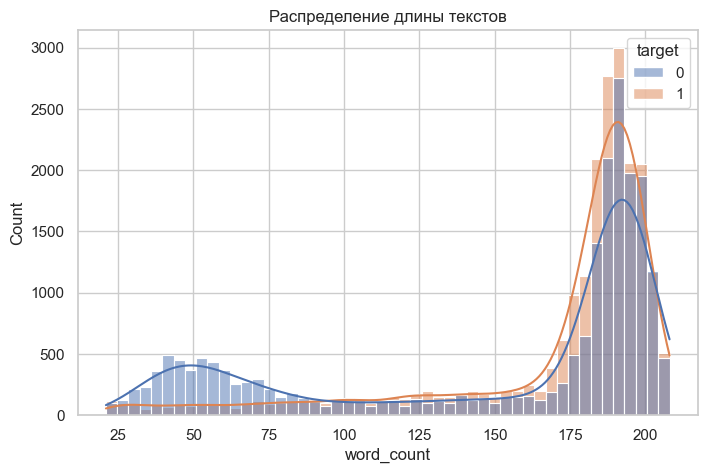

In [333]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="word_count", hue="target", bins=50, kde=True)
plt.title("Распределение длины текстов")
plt.show()

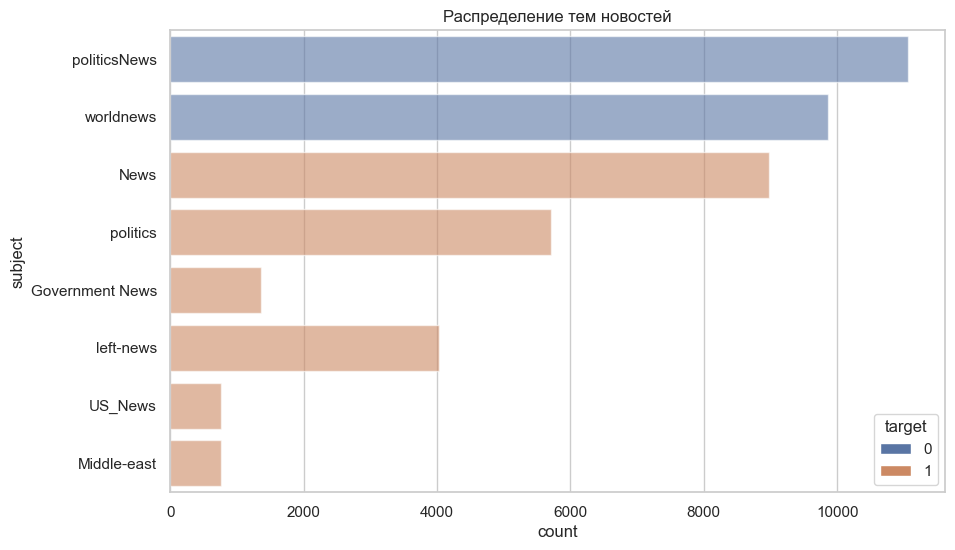

In [334]:
# темы новостей я не буду учитывать
plt.figure(figsize=(10,6))
ax = sns.countplot(y="subject", hue="target", data=df)

for patch in ax.patches:
    patch.set_alpha(0.6)

plt.title("Распределение тем новостей")
plt.show()

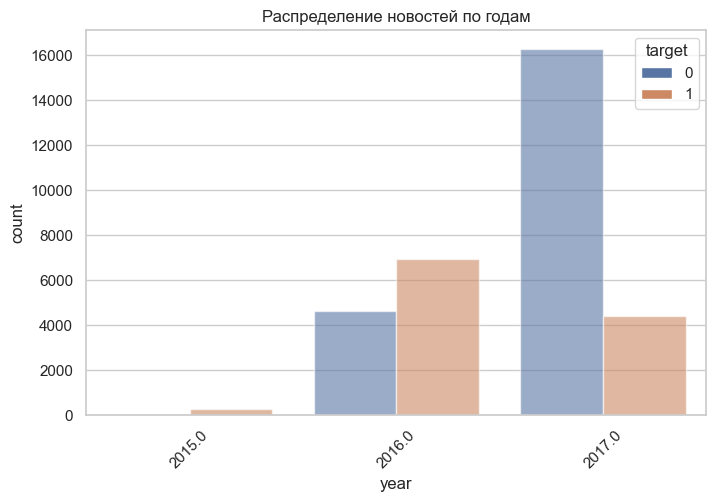

In [335]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x="year", hue="target", data=df)

for patch in ax.patches:
    patch.set_alpha(0.6)

plt.title("Распределение новостей по годам")
plt.xticks(rotation=45)
plt.show()

          word  count
0         with  68220
1           wa  66870
2           ha  50063
3         from  45866
4          not  44495
5         have  44479
6          who  40422
7    president  35601
8        state  35292
9          but  33132
10       would  30095
11       about  29398
12        will  27821
13         had  26373
14       their  25583
15        been  24550
16        year  23959
17       after  23763
18      people  23549
19  republican  23017
20        were  22635
21         one  22081
22         her  22028
23         she  21981
24       which  21834
25         out  20672
26        more  20648
27        what  19174
28         all  19021
29        when  18876
30      donald  18632
31         new  17785
32       house  17357
33          it  17224
34        over  16950
35       obama  16859
36     clinton  16646
37       there  16572
38  government  16470
39        also  16255

Всего уникальных слов: 72563


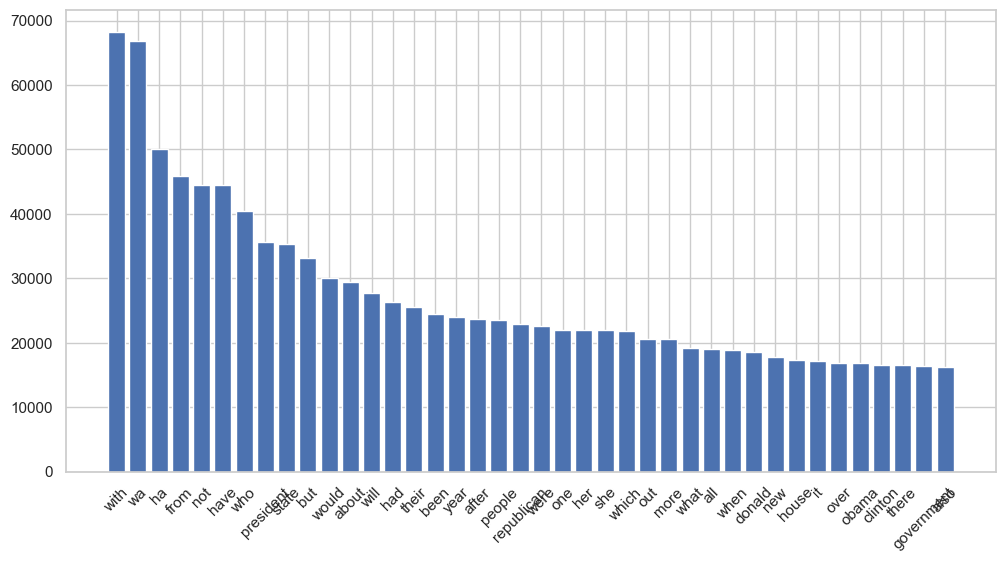

In [336]:
# частота слов

from collections import Counter
import matplotlib.pyplot as plt


all_text = " ".join(df["full_text"].astype(str))

top_n = 40 # сколько слов выводить

words = all_text.split()

word_counts = Counter(words)

sorted_words = word_counts.most_common()

freq_df = pd.DataFrame(sorted_words, columns=["word", "count"])

print(freq_df.head(top_n ))
print("\nВсего уникальных слов:", len(freq_df))

plt.figure(figsize=(12, 6))
plt.bar(freq_df["word"][:top_n], freq_df["count"][:top_n])
plt.xticks(rotation=45)
plt.show()

In [337]:
from collections import Counter
import pandas as pd

# тексты по классам
real_text = " ".join(df[df["target"] == 0]["full_text"].astype(str))
fake_text = " ".join(df[df["target"] == 1]["full_text"].astype(str))

# слова
real_words = real_text.split()
fake_words = fake_text.split()

# частоты
real_counts = Counter(real_words)
fake_counts = Counter(fake_words)

# все уникальные слова
all_words = set(real_counts.keys()) | set(fake_counts.keys())

rows = []

for word in all_words:
    real_count = real_counts.get(word, 0)
    fake_count = fake_counts.get(word, 0)

    diff = fake_count - real_count # + => чаще в fake
    abs_diff = abs(diff)

    rows.append({
        "word": word,
        "real_count": real_count,
        "fake_count": fake_count,
        "diff": diff,
        "abs_diff": abs_diff
    })

diff_df = pd.DataFrame(rows)

diff_df = diff_df.sort_values("abs_diff", ascending=False)

print("ТОП слов с максимальной разницей между классами:")
print(diff_df.head(100))


big_diff = diff_df[diff_df["abs_diff"] > 6000]

with open("../data/processed/high_difference_words.txt", "w", encoding="utf-8") as f:
    for _, row in big_diff.iterrows():
        f.write(
            f"{row['word']} | "
            f"real={row['real_count']} | "
            f"fake={row['fake_count']} | "
            f"diff={row['diff']}\n"
        )

print("\nФайл high_difference_words.txt сохранён")
print("Количество слов:", len(big_diff))

ТОП слов с максимальной разницей между классами:
             word  real_count  fake_count   diff  abs_diff
3230           wa       27666       39204  11538     11538
67679         her        5670       16358  10688     10688
69297         she        5659       16322  10663     10663
46639       about        9476       19922  10446     10446
52865        what        4476       14698  10222     10222
...           ...         ...         ...    ...       ...
21289  republican       12904       10113  -2791      2791
48098       doesn         370        3114   2744      2744
21879   statement        5865        3145  -2720      2720
36830       story         496        3213   2717      2717
26339   spokesman        3163         454  -2709      2709

[100 rows x 5 columns]

Файл high_difference_words.txt сохранён
Количество слов: 23


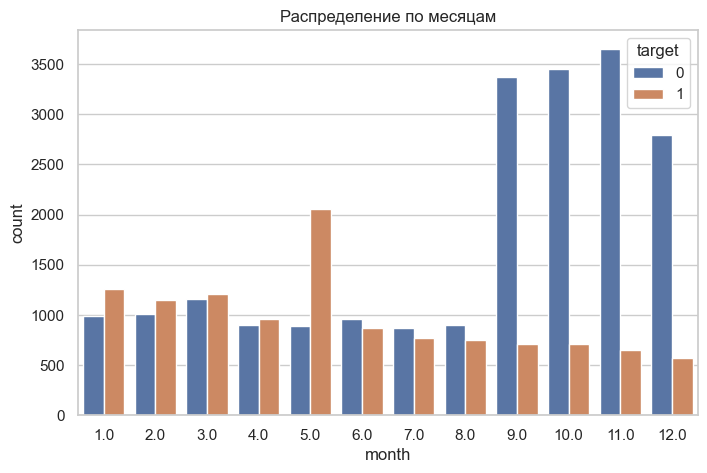

In [338]:
plt.figure(figsize=(8,5))
sns.countplot(x="month", hue="target", data=df)
plt.title("Распределение по месяцам")
plt.show()

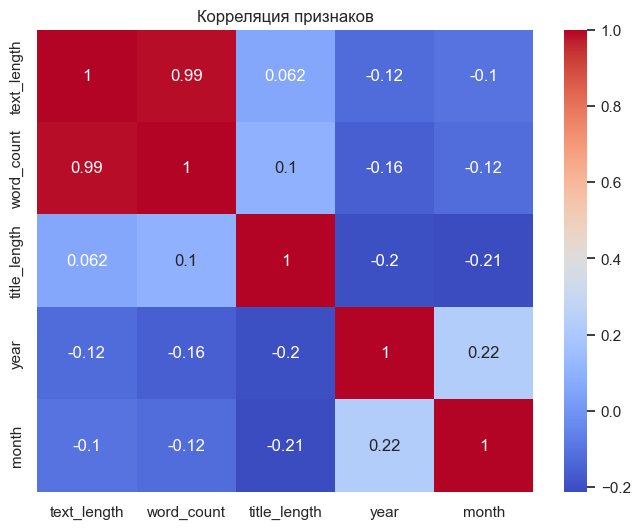

In [339]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["text_length", "word_count", "title_length", "year", "month"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Корреляция признаков")
plt.show()

In [340]:
df.groupby("target")["word_count"].mean()

target
0    150.710388
1    170.863485
Name: word_count, dtype: float64

In [341]:
print(df.groupby("target")[["word_count", "title_length"]].describe())

       word_count                                                           \
            count        mean        std   min    25%    50%    75%    max   
target                                                                       
0         20928.0  150.710388  59.629668  21.0   94.0  185.0  194.0  208.0   
1         21602.0  170.863485  40.621105  21.0  172.0  187.0  194.0  208.0   

       title_length                                                        
              count       mean        std   min   25%   50%    75%    max  
target                                                                     
0           20928.0  64.665329   9.141450  26.0  59.0  64.0   70.0  133.0  
1           21602.0  94.289603  27.171216   8.0  77.0  90.0  105.0  279.0  


## выводы
признаки даты и тематики частично коррелируют: subject нет смысла брать, даты распределены с явным перевесом. Чтобы избежать переобучения, я эти признаки исключу из основной модели.